# 6. A tide and wind hindcast

**What this shows:** a complete SCHISM hindcast of the coast off Perth from 1 to
5 January 2023, forced by the tide and ERA5 winds, then checked and analysed.

**Prerequisites:** Tutorials [1](01_first_model.ipynb) to [5](05_model_settings.ipynb).

**You will learn:**

- how the pieces of the previous tutorials come together in one model
- how to check a SCHISM run beyond "it finished"
- how to read SCHISM's output and separate the tide from the rest of the water level
- how to look at currents and at wetting and drying

**Data used:** `hgrid.gr3`, `tides/` and `era5-perth-20230101-05.nc`.

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pyTMD
import timescale.time
import xarray as xr
from rompy.backends import DockerConfig
from rompy.core.data import DataBlob
from rompy.core.filters import Filter
from rompy.core.source import SourceFile
from rompy.core.time import TimeRange
from rompy.logging import config as logging_config
from rompy.model import ModelRun

from rompy_schism.boundary_core import TidalDataset
from rompy_schism.config import SCHISMConfig
from rompy_schism.data import (
    BoundarySetupWithSource,
    SCHISMData,
    SCHISMDataBoundaryConditions,
    SCHISMDataSflux,
    SfluxAir,
)
from rompy_schism.grid import SCHISMGrid
from rompy_schism.namelists import NML, Param

logging_config.update(level="ERROR")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "06_tide_and_wind_hindcast"
shutil.rmtree(OUT_DIR, ignore_errors=True)
SCHISM_IMAGE = "ghcr.io/rom-py/schism:5.13.0"
CONSTITUENTS = ["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"]
ASPECT = 1 / np.cos(np.radians(32))

## 1. The model

- **Grid:** the Perth mesh, with a drag coefficient that rises in shallow water, as in
  [Tutorial 2](02_mesh_and_vertical_grid.ipynb).
- **Open boundary:** tidal elevation and currents from TPXO9, with nodal corrections
  ([Tutorial 3](03_tides_and_open_boundaries.ipynb)).
- **Atmosphere:** ERA5 wind and pressure ([Tutorial 4](04_atmospheric_forcing.ipynb)).
- **Settings:** barotropic, 2-minute time step, output every 20 minutes in daily
  files, with the water level, depth-averaged currents, wind and the dry flag
  ([Tutorial 5](05_model_settings.ipynb)).

In [2]:
period = TimeRange(start="2023-01-01T00:00", end="2023-01-05T00:00", interval="1h")

hgrid_file = DATA_DIR / "hgrid.gr3"
mesh = SCHISMGrid(hgrid=DataBlob(source=hgrid_file), drag=0.0025).pylibs_hgrid
OUT_DIR.mkdir(parents=True)
mesh.write_hgrid(
    str(OUT_DIR / "drag.gr3"), value=np.interp(mesh.dp, [5.0, 50.0], [0.005, 0.0025])
)
grid = SCHISMGrid(
    hgrid=DataBlob(source=hgrid_file), drag=DataBlob(source=OUT_DIR / "drag.gr3")
)

tides = TidalDataset(
    tidal_database=DATA_DIR / "tides",
    tidal_model="TPXO9-perth",
    constituents=CONSTITUENTS,
    nodal_corrections=True,
)
boundary_conditions = SCHISMDataBoundaryConditions(
    tidal_data=tides,
    default_boundary=BoundarySetupWithSource(elev_type=3, vel_type=3),
)
atmos = SCHISMDataSflux(
    air_1=SfluxAir(
        source=SourceFile(uri=DATA_DIR / "era5-perth-20230101-05.nc"),
        uwind_name="u10",
        vwind_name="v10",
        prmsl_name="msl",
        filter=Filter(sort={"coords": ["latitude"]}),
    )
)
nml = NML(
    param=Param(
        core={"ibc": 1, "ibtp": 0, "dt": 120.0, "nspool": 10, "ihfskip": 720},
        opt={"wtiminc": 3600.0},
        schout={
            "iof_hydro__1": 1,  # water level
            "iof_hydro__14": 1,  # wind
            "iof_hydro__16": 1,  # depth-averaged velocity
            "iof_hydro__26": 0,  # no 3D velocity in a 2D model
        },
    )
)
config = SCHISMConfig(
    grid=grid,
    data=SCHISMData(boundary_conditions=boundary_conditions, atmos=atmos),
    nml=nml,
)

modelrun = ModelRun(run_id="hindcast", period=period, output_dir=OUT_DIR, config=config)
workspace = Path(modelrun())
sorted(p.name for p in workspace.iterdir())

['README',
 'albedo.gr3',
 'bctides.in',
 'datasets',
 'diffmax.gr3',
 'diffmin.gr3',
 'drag.gr3',
 'hgrid.gr3',
 'hgrid.ll',
 'hgrid_WWM.gr3',
 'outputs',
 'param.nml',
 'sflux',
 'tvd.prop',
 'vgrid.in',
 'watertype.gr3',
 'windrot_geo2proj.gr3',
 'wwmbnd.gr3']

## 2. Run it

In [3]:


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


def run_completed(workspace: Path) -> bool:
    """Check SCHISM's log: SCHISM exits with success even when it stops on an error."""
    mirror = workspace / "outputs" / "mirror.out"
    if mirror.exists() and "Run completed successfully" in mirror.read_text():
        return True
    fatal = workspace / "outputs" / "fatal.error"
    print(fatal.read_text() if fatal.exists() else "SCHISM did not finish")
    return False


if docker_available():
    backend = DockerConfig(
        image=SCHISM_IMAGE, executable="schism 2", mpiexec="mpirun", cpu=6
    )
    modelrun.run(backend, workspace_dir=workspace)
completed = run_completed(workspace)
print("SCHISM finished" if completed else "SCHISM did not finish")

SCHISM finished


## 3. Check the run

A finished run is not necessarily a sound one. Three quick checks:

- **`outputs/param.out.nml`**: the settings SCHISM actually used, after its own
  defaults. Worth a look when a setting seems to have no effect.
- **`outputs/mirror.out`**: the log. It reports each time step and warnings; a run
  that is going unstable shows growing values here first.
- **The results themselves**: water levels and currents within sensible limits.

In [4]:
if completed:
    used = (workspace / "outputs" / "param.out.nml").read_text()
    for name in ("DT", "RNDAY", "NWS", "NCHI", "IBC", "DRAMP"):
        line = next(line for line in used.splitlines() if line.strip().startswith(f"{name}="))
        print(line.strip())
    mirror = (workspace / "outputs" / "mirror.out").read_text().splitlines()
    print(f"\nmirror.out: {len(mirror)} lines, ending with:")
    print("\n".join(mirror[-3:]))

DT=  120.00000000000000     ,
RNDAY=  4.0000000000000000     ,
NWS=2          ,
NCHI=0          ,
IBC=1          ,
DRAMP=  1.0000000000000000     ,

mirror.out: 40408 lines, ending with:
TIME STEP=         2880;  TIME=        345600.000000

Run completed successfully at 20260929, 013400.325


In [5]:
if completed:
    out2d = xr.open_mfdataset(
        sorted((workspace / "outputs").glob("out2d_*.nc")),
        data_vars="minimal", coords="minimal", compat="override",
    )  # fmt: skip
    x = out2d.SCHISM_hgrid_node_x.values
    y = out2d.SCHISM_hgrid_node_y.values
    triangulation = mtri.Triangulation(
        x, y, out2d.SCHISM_hgrid_face_nodes.values[:, :3] - 1
    )
    speed = np.hypot(out2d.depthAverageVelX, out2d.depthAverageVelY)
    print(
        f"water level {float(out2d.elevation.min()):.2f} to "
        f"{float(out2d.elevation.max()):.2f} m, "
        f"maximum speed {float(speed.max()):.2f} m/s"
    )

water level -0.39 to 0.39 m, maximum speed 0.77 m/s


## 4. Water levels: the tide and the rest

At three places along the coast, the modelled water level (blue) and the tide
predicted from the TPXO9 constituents (grey). Their difference is what the wind,
pressure and the model's own dynamics add: here a lowering of a few centimetres
under the southerly winds, varying through the day with them.

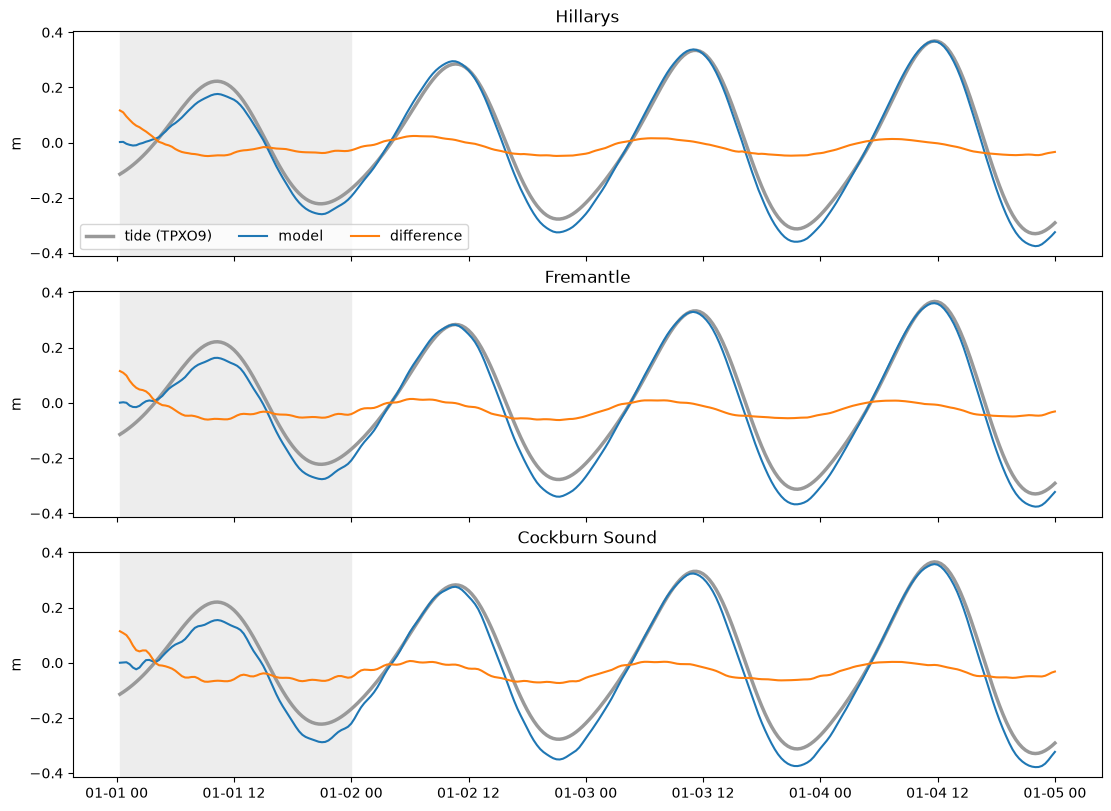

In [6]:


def predicted_tide(lon: float, lat: float, times: np.ndarray) -> np.ndarray:
    """Tide at one point from the TPXO9 constituents, with nodal corrections."""
    database = DATA_DIR / "tides"
    model = pyTMD.io.model(database, extra_databases=[database / "database.json"])
    names = [c.lower() for c in CONSTITUENTS]
    amplitude, phase, _ = model.elevation("TPXO9-perth").extract_constants(
        np.array([lon]), np.array([lat]), constituents=names, method="bilinear"
    )
    constants = amplitude * np.exp(-1j * np.radians(phase))
    ts = timescale.time.Timescale().from_datetime(times.astype("datetime64[s]"))
    return np.asarray(
        pyTMD.predict.time_series(
            ts.tide, constants, names, deltat=ts.tt_ut1, corrections="OTIS"
        )
    ).squeeze()


places = {
    "Hillarys": (115.73, -31.82),
    "Fremantle": (115.72, -32.06),
    "Cockburn Sound": (115.72, -32.20),
}
if completed:
    times = out2d.time.values
    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True, layout="constrained")
    for ax, (name, (lon, lat)) in zip(axes, places.items()):
        node = np.argmin((x - lon) ** 2 + (y - lat) ** 2)
        level = out2d.elevation[:, node].values
        tide = predicted_tide(x[node], y[node], times)
        ax.plot(times, tide, color="0.6", linewidth=2.5, label="tide (TPXO9)")
        ax.plot(times, level, label="model")
        ax.plot(times, level - tide, label="difference")
        ax.axvspan(times[0], np.datetime64("2023-01-02"), color="0.93")
        ax.set(title=name, ylabel="m")
    axes[0].legend(loc="lower left", ncols=3)

## 5. Currents

The strongest currents over the four days (after the ramp) are in the passages
around Rottnest and Garden islands and over the shallow banks, where the tide and the
wind both accelerate the flow. The fastest, in the south-east corner, are the
boundary effect explained in [Tutorial 4](04_atmospheric_forcing.ipynb), not real
currents.

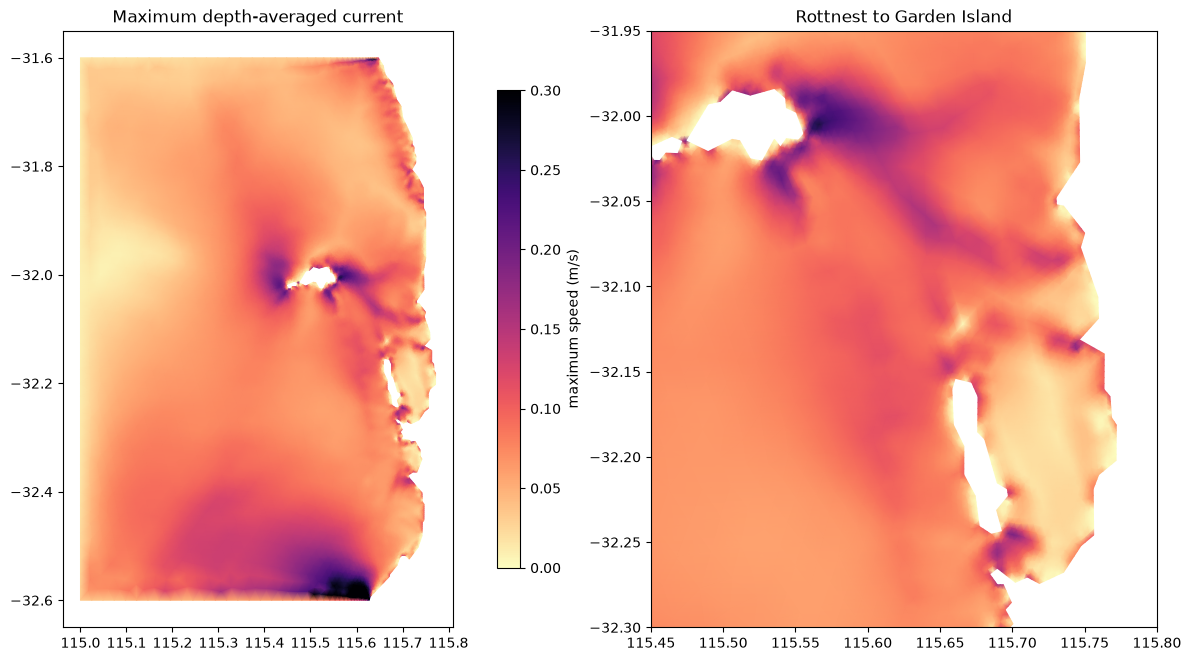

In [7]:
if completed:
    after_ramp = out2d.sel(time=slice("2023-01-02", None))
    maximum = np.hypot(after_ramp.depthAverageVelX, after_ramp.depthAverageVelY).max("time")
    fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), layout="constrained")
    tpc = axes[0].tripcolor(
        triangulation, maximum, cmap="magma_r", shading="gouraud", vmin=0, vmax=0.3
    )
    fig.colorbar(tpc, ax=axes[0], label="maximum speed (m/s)", shrink=0.8)
    axes[0].set(title="Maximum depth-averaged current", aspect=ASPECT)
    axes[1].tripcolor(
        triangulation, maximum, cmap="magma_r", shading="gouraud", vmin=0, vmax=0.3
    )
    axes[1].set(
        title="Rottnest to Garden Island", xlim=(115.45, 115.8), ylim=(-32.3, -31.95),
        aspect=ASPECT,
    )  # fmt: skip

The current in Gage Roads, the anchorage off Fremantle, is weak, under 10 cm/s. It
rises and falls with the diurnal tide, and drifts slowly with the wind over several
days.

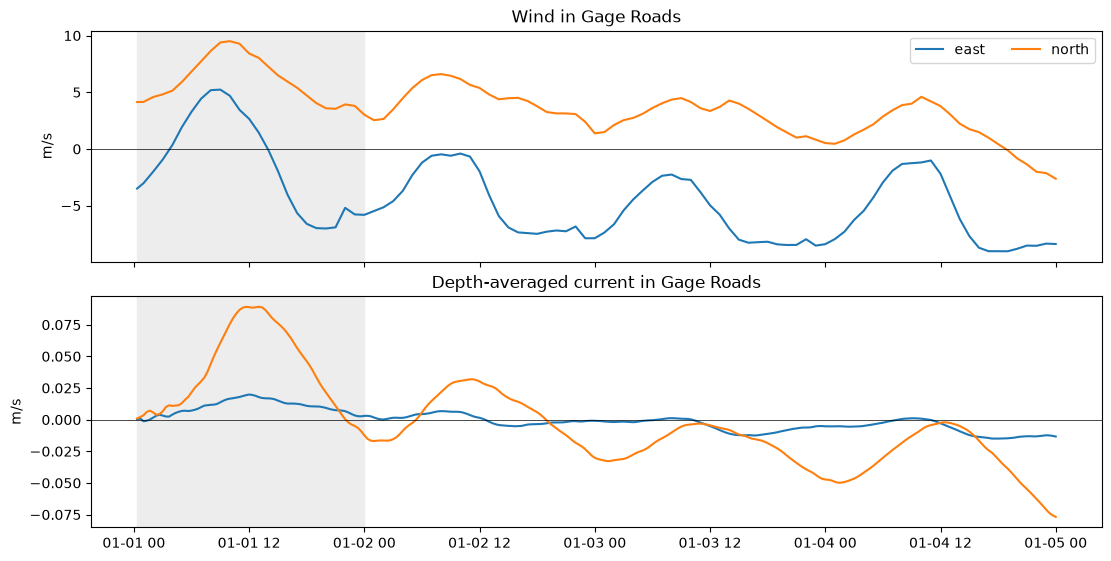

In [8]:
if completed:
    node = np.argmin((x - 115.68) ** 2 + (y + 32.03) ** 2)
    fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True, layout="constrained")
    axes[0].plot(times, out2d.windSpeedX[:, node], label="east")
    axes[0].plot(times, out2d.windSpeedY[:, node], label="north")
    axes[0].set(title="Wind in Gage Roads", ylabel="m/s")
    axes[0].legend(ncols=2)
    axes[1].plot(times, out2d.depthAverageVelX[:, node], label="east")
    axes[1].plot(times, out2d.depthAverageVelY[:, node], label="north")
    axes[1].set(title="Depth-averaged current in Gage Roads", ylabel="m/s")
    for ax in axes:
        ax.axvspan(times[0], np.datetime64("2023-01-02"), color="0.93")
        ax.axhline(0, color="k", linewidth=0.5)

## 6. Wetting and drying

Nodes on the shore dry at low water and flood again at high water. SCHISM flags them
in `dryFlagNode`; mask them before analysing water levels there, since SCHISM still
writes a water level at dry nodes.

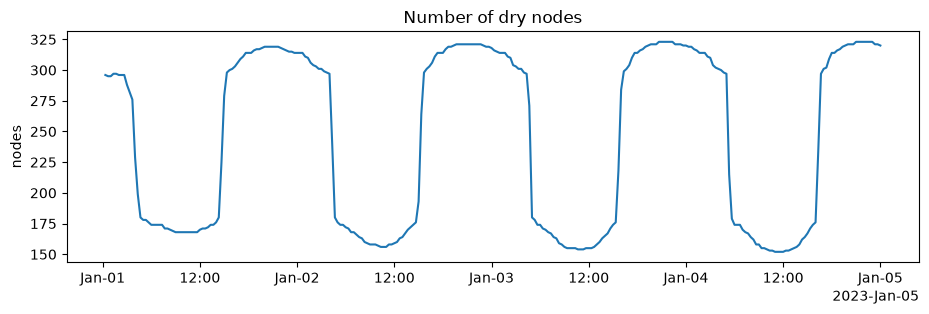

In [9]:
if completed:
    dry = out2d.dryFlagNode.sum("nSCHISM_hgrid_node")
    fig, ax = plt.subplots(figsize=(11, 3))
    dry.plot(ax=ax)
    ax.set(title="Number of dry nodes", ylabel="nodes", xlabel="")

## Summary

- A SCHISM hindcast combines the mesh and friction, the open boundary, the
  atmosphere and the settings of the previous tutorials in one `SCHISMConfig`.
- After a run, check `mirror.out`, `param.out.nml` and the ranges of the results.
- The tide prediction at a point separates the tide from the wind-driven water level.
- Mask dry nodes (`dryFlagNode`) before analysing water levels on the shore.

**Next:** [7. Configuration as YAML and the rompy CLI](07_yaml_and_cli.ipynb).